In [4]:
import scqubits as scq
import numpy as np
def linear_map(x, src_range, target_range):
    src_min, src_max = src_range
    tgt_min, tgt_max = target_range
    return tgt_min + (x - src_min) / (src_max - src_min) * (tgt_max - tgt_min)


q1flux = (-1.1, 3.9) # mA
q4flux = (-1.73, 7.4) # mA

flux = 1.75
q1_nflux = linear_map(flux, q1flux, (1, 0.5))
q4_nflux = linear_map(flux, q4flux, (0.5,1))

q1 = scq.Fluxonium(EJ=3.664, EC=0.945, EL=0.586, cutoff=51, flux=q1_nflux)
q4 = scq.Fluxonium(EJ=3.469, EC=0.952, EL=0.582, cutoff=51, flux=q4_nflux)

print(f'fq1 = {q1.E01()}, at phi = {1 - (q1_nflux% 1)}')
print(f'fq4 = {q4.E01()}, at phi = {1 - (q4_nflux% 1)}')

fq1 = 3.6928362679368427, at phi = 0.28500000000000003
fq4 = 3.234506309021616, at phi = 0.3094194961664841


Spectral data:   0%|          | 0/100 [00:00<?, ?it/s]

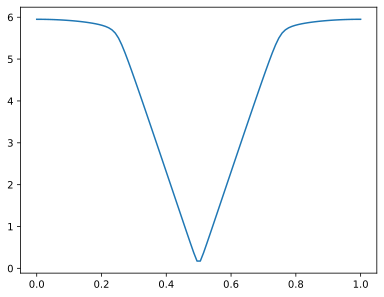

In [10]:
q=scq.Fluxonium(EJ = 5.58, EC=0.96, EL=0.696, cutoff=51, flux=q1_nflux)
eval = q.get_spectrum_vs_paramvals('flux', np.linspace(0, 1, 100),evals_count=5).energy_table
import matplotlib.pyplot as plt
plt.plot(np.linspace(0,1,100), eval[:, 1]- eval[:, 0], label='E01')

In [10]:
import numpy as np
import qutip as qtp
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from qutip import *
%matplotlib inline
import pandas as pd

import scqubits as scq
from scipy import constants
from scipy import interpolate
import scipy

%load_ext autoreload
%autoreload 2

from matplotlib.colors import PowerNorm, ListedColormap
# Choose colormap
cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds
cmap_green = plt.cm.Greens
cmap_purple = plt.cm.Purples
cmap_orange = plt.cm.Oranges

# Get the colormap colors
cmap_blue = cmap_blue(np.arange(plt.cm.Blues.N))
cmap_red = cmap_red(np.arange(plt.cm.Reds.N))
cmap_green = cmap_green(np.arange(plt.cm.Greens.N))
cmap_purple = cmap_purple(np.arange(plt.cm.Purples.N))
cmap_orange = cmap_orange(np.arange(plt.cm.Oranges.N))

# Set alpha
cmap_blue[:,-1] = np.linspace(0, 1, plt.cm.Blues.N)
cmap_red[:,-1] = np.linspace(0, 1, plt.cm.Reds.N)
cmap_green[:,-1] = np.linspace(0, 1, plt.cm.Greens.N)
cmap_purple[:,-1] = np.linspace(0, 1, plt.cm.Purples.N)
cmap_orange[:,-1] = np.linspace(0, 1, plt.cm.Oranges.N)

# Create new colormap
cmap_blue = ListedColormap(cmap_blue)
cmap_red = ListedColormap(cmap_red)
cmap_green = ListedColormap(cmap_green)
cmap_purple = ListedColormap(cmap_purple)
cmap_orange = ListedColormap(cmap_orange)

In [5]:
def build_hilbertspace(E_osc, g, EJ, EC, EL):
    
    fx = scq.Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        flux=0,
        cutoff=100,
        id_str='fluxonium',
    )
    
    res = scq.Oscillator(
        E_osc=E_osc,
        l_osc=1.0,
        truncated_dim=6,
        id_str='resonator',
    )
    
    phi0 = (8*EC/EL)**(1/4)
    fx_n_operator = fx.n_operator()
    fx_phi_operator = fx.phi_operator()
    fx_annihilation = (1j*phi0/np.sqrt(2))*fx_n_operator + (1/(phi0*np.sqrt(2)))*fx_phi_operator
    
    hilbertspace = scq.HilbertSpace([fx, res])
    hilbertspace.add_interaction(
        g=g,
        op1=(fx_annihilation, fx),
        op2=res.creation_operator,
        add_hc=True,
    )

    return hilbertspace

def dressed_resonator_fres(flux, E_osc, g, EJ=None, EC=None, EL=None):  
    if EJ is None:
        EJ = EJ if EJ is not None else 4.75
    if EC is None:
        EC = EC if EC is not None else 1
    if EL is None:
        EL = EL if EL is not None else 1
    
    hilbertspace = build_hilbertspace(E_osc, g, EJ, EC, EL)
    
    def update_hilbertspace(flux):
        hilbertspace.subsys_by_id_str('fluxonium').flux = flux
    sweep = scq.ParameterSweep(
        hilbertspace,
        paramvals_by_name=dict(flux=flux),
        update_hilbertspace=update_hilbertspace,
    )

    fres_pred = sweep.transitions(initial=(0,0), final=(0,1), as_specdata=True).energy_table.squeeze()

    return fres_pred

def fx_res_freqs(flux, E_osc, g, EJ, EC, EL):
    hilbertspace = build_hilbertspace(E_osc, g, EJ, EC, EL)
    
    def update_hilbertspace(flux):
        hilbertspace.subsys_by_id_str('fluxonium').flux = flux
    sweep = scq.ParameterSweep(
        hilbertspace,
        paramvals_by_name=dict(flux=flux),
        update_hilbertspace=update_hilbertspace,
    )
    
    fqub_pred = sweep.transitions(initial=(0,0), final=(1,0), as_specdata=True).energy_table.squeeze()
    fres_pred = sweep.transitions(initial=(0,0), final=(0,1), as_specdata=True).energy_table.squeeze()

    return np.concatenate([fqub_pred, fres_pred])

def sweepdata(flux, E_osc, g, EJ=None, EC=None, EL=None):  
    if EJ is None:
        EJ = EJ if EJ is not None else 4.75
    if EC is None:
        EC = EC if EC is not None else 1
    if EL is None:
        EL = EL if EL is not None else 1
    
    hilbertspace = build_hilbertspace(E_osc, g, EJ, EC, EL)
    
    def update_hilbertspace(flux):
        hilbertspace.subsys_by_id_str('fluxonium').flux = flux
    sweep = scq.ParameterSweep(
        hilbertspace,
        paramvals_by_name=dict(flux=flux),
        update_hilbertspace=update_hilbertspace
    )


    return sweep

In [17]:
import numpy as np
import matplotlib.pyplot as plt
EJ=3.664
EC=0.945
EL=0.586

EJ=3.469
EC=0.952
EL=0.582


E_osc=5.8

flux = np.linspace(0, 0.5, 101)
sd = sweepdata(flux, E_osc, 0.06, EJ=EJ, EC=EC, EL=EL)

Bare spectra:   0%|          | 0/101 [00:00<?, ?it/s]

Bare spectra:   0%|          | 0/101 [00:00<?, ?it/s]

Dressed spectrum:   0%|          | 0/101 [00:00<?, ?it/s]

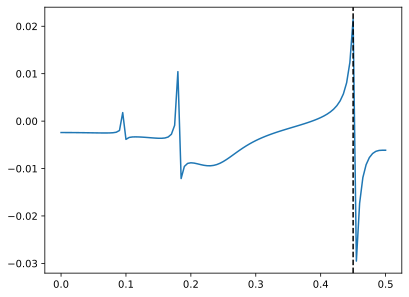

In [18]:
chi = sd["chi"]["subsys1":0, "subsys2":1]
plt.plot(flux, chi[:,1])
plt.axvline(0.45, color='k', linestyle='--')

In [38]:
res = 5.351
q1.flux = 0.5

q = q1
print('f01',q.E01())
print('f12',q.eigenvals()[2] - q.eigenvals()[0])
print('f0g1',res -(q.eigenvals()[2] - q.eigenvals()[0]))

f01 0.30891612555761805
f12 3.6337218739140256
f0g1 1.7172781260859744


In [15]:
from qick.helpers import folded_freq
print('folded freq', folded_freq(q4.E01(), 6881.280))

folded freq 1.896944550964107


In [35]:
pulse_name_seq.append(total_clifford)
print("Operate gate:", pulse_name_seq)

Operate gate: ['X/2', 'X/2', 'X/2,-Y/2,-X/2', 'X/2', 'Y/2,-X/2']


In [32]:

pulse_name_seq.reverse()
print("Experience sequence:", pulse_name_seq)

Experience sequence: ['I', 'X/2', '-Y/2,X/2', 'X/2', 'Y/2,X/2']


In [33]:

expanded_sequence = [gate for name in pulse_name_seq for gate in name.split(",")]
print("Expanded sequence:", expanded_sequence)

Expanded sequence: ['I', 'X/2', '-Y/2', 'X/2', 'X/2', 'Y/2', 'X/2']


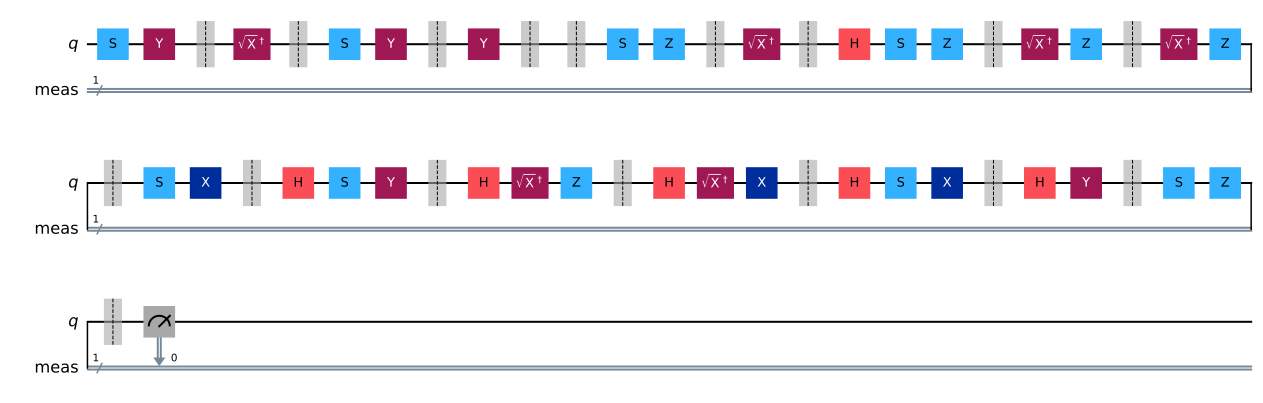

In [26]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


lengths = np.arange(1, 100, 5)
num_samples = 10
seed = 1010
qubits = [0]
exp1 = StandardRB(qubits, lengths, num_samples=num_samples, seed=seed)
c = exp1.circuits()[3]
c.decompose().draw(output="mpl", style="iqp")

In [ ]:
# xdata = np.arange(10,60,5)
xdata = np.unique(np.logspace(0.4,2.5,15).astype(int))
xunit = 'its'
xname = 'Number of Cliffords'

ydata_list = np.arange(60)
yunit = ''
yname = 'Number of Samples'

if interleave:
    exp = InterleavedRB(XGate(), [0], xdata, num_samples=len(ydata_list))
    circs = exp.circuits()[1::2]
    tag = 'RB/interleaved'
else:
    exp = StandardRB([0], xdata, num_samples=len(ydata_list))
    circs = exp.circuits()
    tag = 'RB/standard'

In [ ]:
from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate

xdata = np.unique(np.logspace(0.4,2.5,15).astype(int))
ydata_list = np.arange(60)
exp = StandardRB([2], xdata, num_samples=100, seed=123)
# exp = InterleavedRB(XGate(), [0], xdata, num_samples=len(ydata_list))
circs = exp.circuits()
qasm = transpile(circs[5].decompose(), basis_gates = ['rx','ry'])
qasm.draw()

global phase: π/4
        ┌─────────┐┌───────┐ ░ ┌────────┐ ░ ┌──────────┐┌──────────┐ ░ »
     q: ┤ Ry(π/2) ├┤ Rx(π) ├─░─┤ Rx(-π) ├─░─┤ Rx(-π/2) ├┤ Ry(-π/2) ├─░─»
        └─────────┘└───────┘ ░ └────────┘ ░ └──────────┘└──────────┘ ░ »
meas: 1/═══════════════════════════════════════════════════════════════»
                                                                       »
«        ┌────────┐ ░ ┌─────────┐┌──────────┐┌──────────┐ ░ ┌────────┐ ░ »
«     q: ┤ Rx(-π) ├─░─┤ Rx(π/2) ├┤ Ry(-π/2) ├┤ Rx(-π/2) ├─░─┤ Rx(-π) ├─░─»
«        └────────┘ ░ └─────────┘└──────────┘└──────────┘ ░ └────────┘ ░ »
«meas: 1/════════════════════════════════════════════════════════════════»
«                                                                        »
«        ┌─────────┐ ░ ┌────────┐ ░ ┌─────────┐┌──────────┐ ░ ┌────────┐ ░ »
«     q: ┤ Rx(π/2) ├─░─┤ Rx(-π) ├─░─┤ Ry(π/2) ├┤ Rx(-π/2) ├─░─┤ Rx(-π) ├─░─»
«        └─────────┘ ░ └────────┘ ░ └─────────┘└──────────┘ ░ └────────┘ ░ »
«meas: 1/══════════════════════════════════════════════════════════════════»
«                                                                          »
«        ┌─────────┐┌──────────┐┌──────────┐ ░ ┌─┐
«     q: ┤ Rx(π/2) ├┤ Ry(-π/2) ├┤ Rx(-π/2) ├─░─┤M├
«        └─────────┘└──────────┘└──────────┘ ░ └╥┘
«meas: 1/═══════════════════════════════════════╩═
«                                               0

In [63]:
from qiskit import transpile
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit.circuit.library import XGate

xdata = np.unique(np.logspace(0.4,2.5,15).astype(int))
ydata_list = np.arange(60)
exp = StandardRB([2], xdata, num_samples=1)
exp = InterleavedRB(XGate(), [0], xdata, num_samples=5, seed=123)
circs = exp.circuits()
qasm = transpile(circs[5].decompose(), basis_gates = ['rx','ry'])
qasm.draw()

global phase: 3π/2
         ░ ┌────────┐ ░ ┌─────────┐┌─────────┐┌─────────┐ ░ ┌────────┐ ░ »
     q: ─░─┤ Rx(-π) ├─░─┤ Rx(π/2) ├┤ Ry(π/2) ├┤ Rx(π/2) ├─░─┤ Rx(-π) ├─░─»
         ░ └────────┘ ░ └─────────┘└─────────┘└─────────┘ ░ └────────┘ ░ »
meas: 1/═════════════════════════════════════════════════════════════════»
                                                                         »
«        ┌──────────┐┌───────┐ ░ ┌────────┐ ░ ┌─────────┐┌───────┐ ░ ┌────────┐»
«     q: ┤ Rx(-π/2) ├┤ Ry(π) ├─░─┤ Rx(-π) ├─░─┤ Ry(π/2) ├┤ Rx(π) ├─░─┤ Rx(-π) ├»
«        └──────────┘└───────┘ ░ └────────┘ ░ └─────────┘└───────┘ ░ └────────┘»
«meas: 1/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«         ░ ┌──────────┐┌─────────┐ ░ ┌────────┐ ░ ┌─────────┐┌─────────┐»
«     q: ─░─┤ Ry(-π/2) ├┤ Rx(π/2) ├─░─┤ Rx(-π) ├─░─┤ Rx(π/2) ├┤ Ry(π/2) ├»
«         ░ └──────────┘└─────────┘ ░ └────────┘ ░ └─────────┘└─────────┘»
«meas: 1/════════════════════════════════════════════════════════════════»
«                                                                        »
«        ┌─────────┐ ░ ┌─┐
«     q: ┤ Rx(π/2) ├─░─┤M├
«        └─────────┘ ░ └╥┘
«meas: 1/═══════════════╩═
«                       0

In [50]:
import numpy as np

"""
Define matrices representing (all) Clifford gates for single
qubit in the basis of Z, X, Y, -Z, -X, -Y, indicating
where on the 6 cardinal points of the Bloch sphere the
+Z, +X, +Y axes go after each gate. Each Clifford gate
can be uniquely identified just by checking where +X and +Y
go.
"""
clifford_1q = dict()
# clifford_1q["Z"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 0, 0, 1, 0, 0],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#     ]
# )
clifford_1q["X"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
    ]
)
clifford_1q["Y"] = np.matrix(
    [
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#     ]
# )
clifford_1q["X/2"] = np.matrix(
    [
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
    ]
)
clifford_1q["Y/2"] = np.matrix(
    [
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
# clifford_1q["-Z/2"] = np.matrix(
#     [
#         [1, 0, 0, 0, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 0, 0, 0, 1],
#         [0, 1, 0, 0, 0, 0],
#     ]
# )
clifford_1q["-X/2"] = np.matrix(
    [
        [0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0],
    ]
)
clifford_1q["-Y/2"] = np.matrix(
    [
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1],
    ]
)
identity = np.diag([1] * 6)
clifford_1q["I"] = identity


# Read pulse as a matrix product acting on state (meaning apply pulses in reverse order of the tuple)
# two_step_pulses = [
#     ("X", "Z/2"),
#     ("X/2", "Z/2"),
#     ("-X/2", "Z/2"),
#     ("Y", "Z/2"),
#     ("Y/2", "Z/2"),
#     ("-Y/2", "Z/2"),
#     ("X", "Z"),
#     ("X/2", "Z"),
#     ("-X/2", "Z"),
#     ("Y", "Z"),
#     ("Y/2", "Z"),
#     ("-Y/2", "Z"),
#     ("X", "-Z/2"),
#     ("X/2", "-Z/2"),
#     ("-X/2", "-Z/2"),
#     ("Y", "-Z/2"),
#     ("Y/2", "-Z/2"),
#     ("-Y/2", "-Z/2"),
# ]

step_pulses = [
    ("Y/2", "X"),
    ("Y/2", "X/2"),
    ("X/2", "-Y/2", "-X/2"),
    ("-X/2", "-Y/2"),
    ("Y/2", "-X/2"),
    ("-X/2", "Y/2", "-X/2"),
    ("X/2", "Y/2"),
    ("-Y/2", "X"),
    ("-X/2", "Y"),
    ("-Y/2", "-X/2"),
    ("X/2", "Y/2", "X/2"),
    ("-X/2", "Y/2"),
    ("X", "Y"),
    ("X/2", "Y"),
    ("-Y/2", "X/2"),
    ("X/2", "Y/2", "-X/2"),
    ("X/2", "-Y/2"),
]

for pulse in step_pulses:
    new_mat = clifford_1q[pulse[0]]
    for p in pulse[1:]:
        new_mat = new_mat @ clifford_1q[p]
    repeat = False
    # Make sure there are no repeats
    for existing_pulse_name, existing_pulse in clifford_1q.items():
        if np.array_equal(new_mat, existing_pulse):
            print("found repeat", pulse, existing_pulse_name)
            repeat = True
    if not repeat:
        clifford_1q[pulse[0] + "," + ",".join(pulse[1:])] = new_mat
clifford_1q_names = list(clifford_1q.keys())
assert (
    len(clifford_1q_names) == 24
), f"you have {len(clifford_1q_names)} elements in your Clifford group instead of 24!"
# print(len(clifford_1q_names), "elements in clifford_1q")
# print(clifford_1q_names)

# Get the average number of X/2 gates per Clifford gate
count = 0
for n in range(len(clifford_1q_names)):  # n is index in clifford_1q_names
    gates = clifford_1q_names[n].split(",")
    for gate in gates:
        # print(gate)
        if gate == "I" or "Z" in gate:
            continue
        if "/2" in gate:
            count += 1
            # print("added 1 to count")
        else:
            count += 2
            # print("added 2 to count")
# print("Average number of X/2 gates per Clifford gate:", count / len(clifford_1q_names))

for name, matrix in clifford_1q.items():
    z_new = np.argmax(matrix[:, 0])  # +Z goes to row where col 0 is 1
    x_new = np.argmax(matrix[:, 1])  # +X goes to row where col 1 is 1
    # print(name, z_new, x_new)
    clifford_1q[name] = (matrix, (z_new, x_new))


def gate_sequence(rb_depth, pulse_n_seq=None, debug=False):
    """
    Generate RB forward gate sequence of length rb_depth as a list of pulse names;
    also return the Clifford gate that is equivalent to the total pulse sequence.
    The effective inverse is pi phase + the total Clifford.
    Optionally, provide pulse_n_seq which is a list of the indices of the Clifford
    gates to apply in the sequence.
    """
    if pulse_n_seq is None:
        pulse_n_seq = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_name_seq = [clifford_1q_names[n] for n in pulse_n_seq]
    if debug:
        print("pulse seq", pulse_name_seq)
    psi_nz = np.matrix([[1, 0, 0, 0, 0, 0]]).transpose()
    psi_nx = np.matrix([[0, 1, 0, 0, 0, 0]]).transpose()
    for n in pulse_n_seq:  # n is index in clifford_1q_names
        gates = clifford_1q_names[n].split(",")
        for gate in reversed(gates):  # Apply matrices from right to left of gates
            psi_nz = clifford_1q[gate][0] @ psi_nz
            psi_nx = clifford_1q[gate][0] @ psi_nx
    psi_nz = psi_nz.flatten()
    psi_nx = psi_nx.flatten()
    if debug:
        print("+Z axis after seq:", psi_nz, "+X axis after seq:", psi_nx)

    total_clifford = None
    if np.argmax(psi_nz) == 0:
        total_clifford = "I"
    else:
        for clifford in clifford_1q_names:  # Get the clifford equivalent to the total seq
            if clifford_1q[clifford][1] == (np.argmax(psi_nz), np.argmax(psi_nx)):
                # z_new, x_new = clifford_1q[clifford][1]
                # if z_new == np.argmax(psi_nz):
                total_clifford = clifford
                break
    assert total_clifford is not None, f"Failed to invert gate sequence! {pulse_name_seq} which brings +Z to {psi_nz}"

    if debug:
        total_clifford_mat = clifford_1q[total_clifford][0]
        print("Total gate matrix:\n", total_clifford_mat)

    return pulse_name_seq, total_clifford


def interleaved_gate_sequence(rb_depth, gate_char: str, debug=False):
    """
    Generate RB gate sequence with rb_depth random gates interleaved with gate_char
    Returns the total gate list (including the interleaved gates) and the total
    Clifford gate equivalent to the total pulse sequence.
    """
    pulse_n_seq_rand = (len(clifford_1q_names) * np.random.rand(rb_depth)).astype(int)
    pulse_n_seq = []
    assert gate_char in clifford_1q_names
    n_gate_char = clifford_1q_names.index(gate_char)
    if debug:
        print("n gate char:", n_gate_char, clifford_1q_names[n_gate_char])
    for n_rand in pulse_n_seq_rand:
        pulse_n_seq.append(n_rand)
        pulse_n_seq.append(n_gate_char)
    return gate_sequence(len(pulse_n_seq), pulse_n_seq=pulse_n_seq, debug=debug)

def expand_full_sequence(pulse_name_seq, total_clifford):
    """
    Expand a full pulse_name_seq into the actual play sequence, handling normal and inverse gates correctly.
    
    Args:
        pulse_name_seq : list of str
            Example: ['X/2', 'X/2', 'X/2,-Y/2,-X/2', 'X/2']
        total_clifford : str
            Example: 'Y/2,-X/2'
    
    Returns:
        list of str
            Final flat sequence to be played on hardware
    """
    full_sequence = []

    # Expand normal pulse names (right-to-left)
    for name in pulse_name_seq:
        gates = name.split(",")
        for g in reversed(gates):   # right-to-left
            full_sequence.append(g)

    # Expand total_clifford separately (left-to-right)
    for gate in total_clifford.split(","):
        neg = "-" in gate
        neg = not neg  # invert the meaning because it's inverted

        # 修正 gate 名字
        if neg:
            if "-" not in gate:
                gate = "-" + gate
            # else: 本來有 "-", neg反了就保留
        else:
            if "-" in gate:
                gate = gate.replace("-", "")  # 去掉負號

        full_sequence.append(gate)
    return full_sequence


if __name__ == "__main__":
    print("Clifford gates:", clifford_1q_names)
    print("Total number Clifford gates:", len(clifford_1q_names))
    pulse_name_seq, total_clifford = gate_sequence(5, debug=True)
    print("Pulse sequence:", pulse_name_seq)
    print("Total clifford of seq:", total_clifford)
    print("Operate gate:", expand_full_sequence(pulse_name_seq, total_clifford))

    # gate_char = "X/2"
    # print()
    # print("Interleaved RB with gate", gate_char)
    # pulse_name_seq, total_clifford = interleaved_gate_sequence(2, gate_char=gate_char, debug=True)
    # print("Pulse sequence:", pulse_name_seq)
    # print("Total clifford of seq:", total_clifford)
    # pulse_name_seq.append(total_clifford)
    # print("Operate gate:", expand_full_sequence(pulse_name_seq, total_clifford))

Clifford gates: ['X', 'Y', 'X/2', 'Y/2', '-X/2', '-Y/2', 'I', 'Y/2,X', 'Y/2,X/2', 'X/2,-Y/2,-X/2', '-X/2,-Y/2', 'Y/2,-X/2', '-X/2,Y/2,-X/2', 'X/2,Y/2', '-Y/2,X', '-X/2,Y', '-Y/2,-X/2', 'X/2,Y/2,X/2', '-X/2,Y/2', 'X,Y', 'X/2,Y', '-Y/2,X/2', 'X/2,Y/2,-X/2', 'X/2,-Y/2']
Total number Clifford gates: 24
pulse seq ['Y', 'I', 'X,Y', 'X/2,-Y/2,-X/2', 'Y/2,-X/2']
+Z axis after seq: [[0 0 0 0 0 1]] +X axis after seq: [[0 1 0 0 0 0]]
Total gate matrix:
 [[0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [1 0 0 0 0 0]]
Pulse sequence: ['Y', 'I', 'X,Y', 'X/2,-Y/2,-X/2', 'Y/2,-X/2']
Total clifford of seq: X/2
Operate gate: ['Y', 'I', 'Y', 'X', '-X/2', '-Y/2', 'X/2', '-X/2', 'Y/2', '-X/2']


In [119]:

import pandas as pd
import matplotlib.pyplot as plt

def plot_t1_time_series(file="t1_monitor_log.csv"):
    df = pd.read_csv(file, parse_dates=["timestamp"])

    plt.figure(figsize=(10, 5))
    plt.plot(df["timestamp"], df["q1_t1"], label="q1 T1", marker="o")
    plt.plot(df["timestamp"], df["q4_t1"], label="q4 T1", marker="o")
    plt.xlabel("Time")
    plt.ylabel("T1 Value")
    plt.title("T1 vs. Time")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_t1_histogram(file="t1_monitor_log.csv", bins=30):
    df = pd.read_csv(file)

    plt.figure(figsize=(10, 4))

    plt.hist(df["q1_t1"], bins=bins, alpha=0.6, label="q1 T1")
    plt.hist(df["q4_t1"], bins=bins, alpha=0.6, label="q4 T1")
    plt.xlabel("T1 Value")
    plt.ylabel("Count")
    plt.title("T1 Distribution Histogram")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


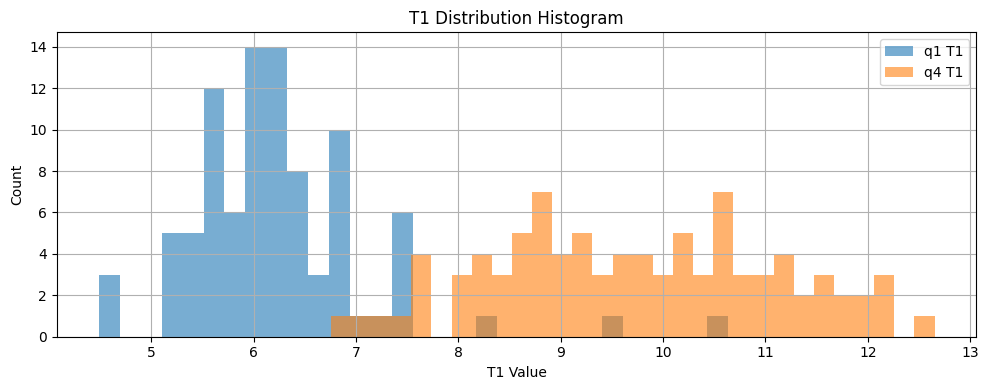

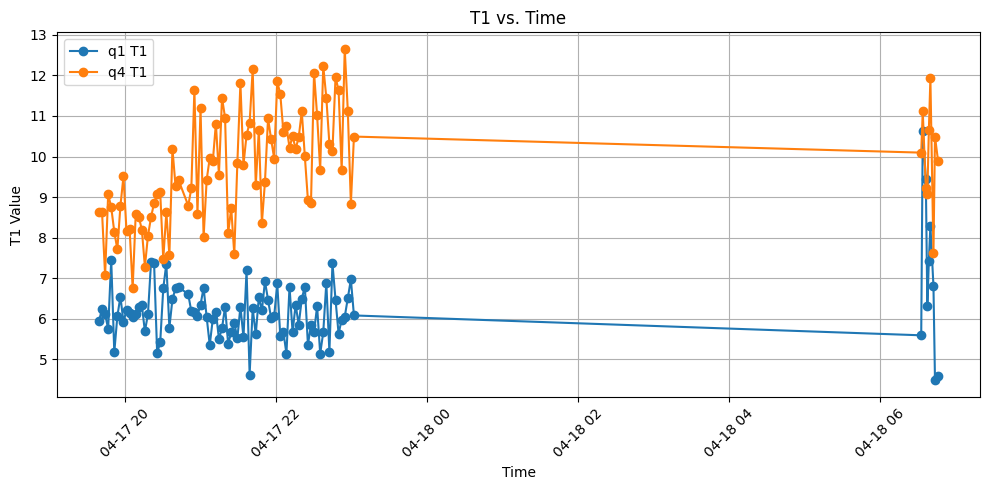

In [120]:
plot_t1_histogram()
plot_t1_time_series()

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_t1_with_hist(file="t1_monitor_log.csv"):
    df = pd.read_csv(file, parse_dates=["timestamp"])

    fig = plt.figure(figsize=(12, 5))
    gs = GridSpec(1, 4, width_ratios=[4, 0.1, 1, 0.1]) # 主圖 + 空隙 + hist + 邊框空白

    # 時間序列圖（左側）
    ax_main = fig.add_subplot(gs[0])
    ax_main.plot(df["timestamp"], df["q1_t1"], label="q1 T1", marker="o", ls='-', lw=2, alpha=0.5)
    ax_main.plot(df["timestamp"], df["q4_t1"], label="q4 T1", marker="o", ls='-', lw=2, alpha=0.5)
    ax_main.set_xlabel("Time")
    ax_main.set_ylabel("T1 Value")
    ax_main.set_title("T1 vs Time with Distribution")
    ax_main.legend()
    ax_main.grid(True)
    ax_main.tick_params(axis='x', rotation=45)

    # 垂直 histogram（右側）
    ax_hist = fig.add_subplot(gs[2], sharey=ax_main)
    ax_hist.hist(df["q1_t1"], bins=20, orientation='horizontal', alpha=0.6, label="q1 T1")
    ax_hist.hist(df["q4_t1"], bins=20, orientation='horizontal', alpha=0.6, label="q4 T1")
    ax_hist.set_xlabel("Count")
    ax_hist.yaxis.set_tick_params(labelleft=False) # 不顯示 y 軸標籤（已在左邊）

    plt.tight_layout()
    plt.show()
    return len(df["q4_t1"])


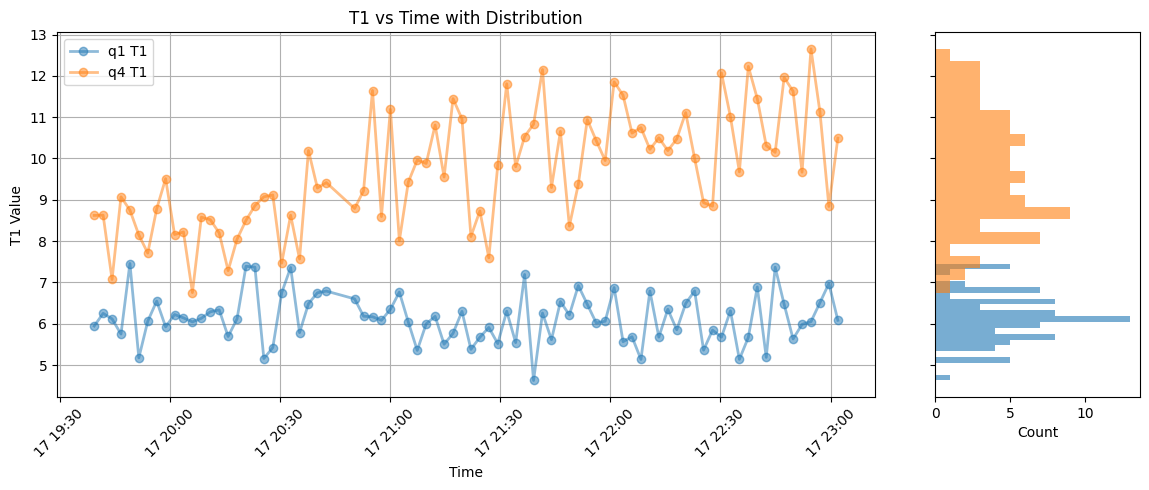

82

In [124]:
plot_t1_with_hist()

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_t1_with_hist(file="t1_interleaved_monitor_log.csv"):
    df = pd.read_csv(file, parse_dates=["timestamp"])
    df["i"] = df.index

    # 分組資料
    group0 = df[df["i"] % 3 == 0]  # MuxT1_together
    group1 = df[df["i"] % 3 == 1]  # MuxT1_onlyoneq
    group2 = df[df["i"] % 3 == 2]  # MuxT1_onlyoneq_onetone

    color0 = "#1f77b4"  # 藍
    color1 = "#ff7f0e"  # 橘
    color2 = "#2ca02c"  # 綠

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 4, height_ratios=[3, 2], width_ratios=[4, 0.1, 1, 0.1])

    # --- top plot ---
    ax_main = fig.add_subplot(gs[0, 0])
    ax_main.plot(df["timestamp"], df["q1_t1"], label="q1 T1", marker="o", ls='-', lw=2, alpha=0.5)
    ax_main.plot(df["timestamp"], df["q4_t1"], label="q4 T1", marker="o", ls='-', lw=2, alpha=0.5)
    ax_main.set_xlabel("Time")
    ax_main.set_ylabel("T1 Value")
    ax_main.set_title("T1 vs Time (All)")
    ax_main.legend()
    ax_main.grid(True)
    ax_main.tick_params(axis='x', rotation=45)
    ax_main.set_ylim(0, 30)

    # --- top histogram ---
    ax_hist_top = fig.add_subplot(gs[0, 2], sharey=ax_main)
    # 僅保留 0~50 的值再畫 histogram
    q1_inrange = df["q1_t1"].dropna()
    q1_inrange = q1_inrange[(q1_inrange >= 0) & (q1_inrange <= 50)]

    q4_inrange = df["q4_t1"].dropna()
    q4_inrange = q4_inrange[(q4_inrange >= 0) & (q4_inrange <= 50)]

    ax_hist_top.hist(q1_inrange, bins=20, orientation='horizontal',
                    alpha=0.6, label="q1 T1", color=color0, density=True)
    ax_hist_top.hist(q4_inrange, bins=20, orientation='horizontal',
                    alpha=0.6, label="q4 T1", color=color1, density=True)
    ax_hist_top.set_xlabel("Density")
    ax_hist_top.set_ylim([0, 30])  # 限制 y 軸為 0~50


    # --- down plot ---
    ax_group = fig.add_subplot(gs[1, 0])
    ax_group.plot(group0["timestamp"], group0["q4_t1"], 'o-', label="q4 (MuxT1_together)", color=color0)
    ax_group.plot(group1["timestamp"], group1["q4_t1"], 'x--', label="q4 (MuxT1_onlyoneq)", color=color1)
    ax_group.plot(group2["timestamp"], group2["q4_t1"], 's-.', label="q4 (MuxT1_onlyoneq_onetone)", color=color2)
    ax_group.set_xlabel("Time")
    ax_group.set_ylabel("q4 T1 Value")
    ax_group.set_title("q4 T1 per Measurement Mode")
    ax_group.legend()
    ax_group.grid(True)
    ax_group.tick_params(axis='x', rotation=45)

    # --- down histogram---
    ax_hist_bottom = fig.add_subplot(gs[1, 2], sharey=ax_group)
    ax_hist_bottom.hist(group0["q4_t1"].dropna(), bins=15, orientation='horizontal',
                        alpha=0.6, label="MuxT1_together", color=color0)
    ax_hist_bottom.hist(group1["q4_t1"].dropna(), bins=15, orientation='horizontal',
                        alpha=0.6, label="MuxT1_onlyoneq", color=color1)
    ax_hist_bottom.hist(group2["q4_t1"].dropna(), bins=15, orientation='horizontal',
                        alpha=0.6, label="MuxT1_onlyoneq_onetone", color=color2)
    ax_hist_bottom.set_xlabel("Count")
    ax_hist_bottom.yaxis.set_tick_params(labelleft=False)

    plt.tight_layout()
    plt.show()
    return len(df)


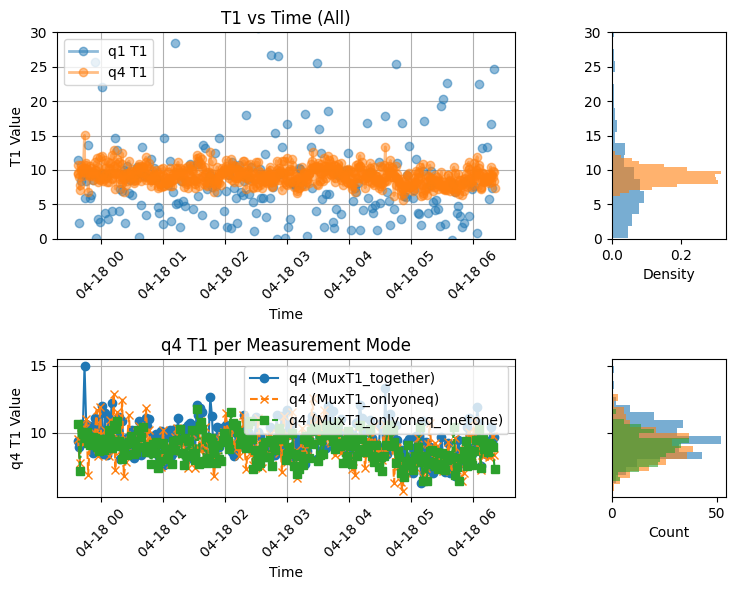

738

In [122]:
plot_t1_with_hist()

In [94]:
def plot_t1_with_hist(file="t1_interleaved_monitor_log.csv"):
    df = pd.read_csv(file, parse_dates=["timestamp"])
    q1t1 = df["q1_t1"].dropna()
    plt.hist(q1t1, bins=20, 
                    alpha=0.6, label="q1 T1")
    return(df["q1_t1"].dropna())

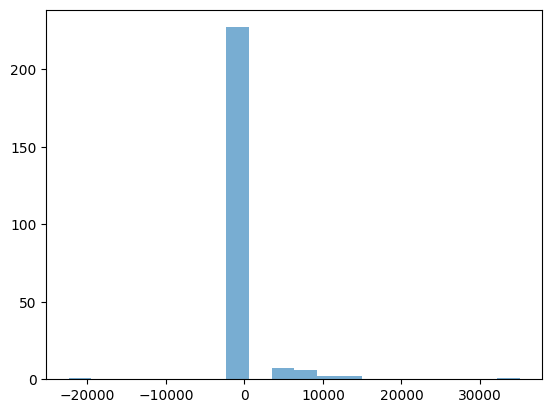

In [95]:
t1 = plot_t1_with_hist()

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ast

def plot_t1_t2_timeseries_with_hist(file="monitor_log.csv"):
    df = pd.read_csv(file, parse_dates=["timestamp"])

    # 解析字串成 list
    df["T2r"] = df["T2r"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [None, None])
    df["T2e"] = df["T2e"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [None, None])

    # 拆成各欄
    df["T2r_time"] = df["T2r"].apply(lambda x: x[0])
    df["T2r_detune"] = df["T2r"].apply(lambda x: x[1])
    df["T2e_time"] = df["T2e"].apply(lambda x: x[0])
    df["T2e_detune"] = df["T2e"].apply(lambda x: x[1])

    # 使用 GridSpec 進行主圖與 histogram 的排版
    fig = plt.figure(figsize=(8, 10))
    gs = gridspec.GridSpec(3, 2, width_ratios=[4, 1], wspace=0.2, hspace=0.4)

    # --- 第一行：T1 ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1_hist = fig.add_subplot(gs[0, 1], sharey=ax1)

    ax1.plot(df["timestamp"], df["T1"], marker="o", color="C0", label="T1")
    ax1.set_ylabel("T1 [us]")
    ax1.grid(True)
    ax1.legend()
    ax1.tick_params(labelbottom=False)
    ax1_hist.hist(df["T1"].dropna(), bins=20, orientation="horizontal", color="C0", alpha=0.6)
    ax1_hist.set_xlabel("Count")
    ax1_hist.grid(True)

    # --- 第二行：T2 Time ---
    ax2 = fig.add_subplot(gs[1, 0])
    ax2_hist = fig.add_subplot(gs[1, 1], sharey=ax2)

    ax2.plot(df["timestamp"], df["T2r_time"], marker="o", label="T2R time", color="C1")
    ax2.plot(df["timestamp"], df["T2e_time"], marker="o", label="T2E time", color="C2")
    ax2.set_ylabel("T2 Time [us]")
    ax2.grid(True)
    ax2.legend()
    ax2.tick_params(labelbottom=False)
    ax2.set_ylim(0,50)
    ax2_hist.hist(df["T2r_time"].dropna(), bins=100, orientation="horizontal", color="C1", alpha=0.6, label="T2R")
    ax2_hist.hist(df["T2e_time"].dropna(), bins=100, orientation="horizontal", color="C2", alpha=0.6, label="T2E")
    ax2_hist.set_xlabel("Count")
    ax2_hist.grid(True)
    ax2_hist.legend()
    
    # --- 第三行：Detune ---
    ax3 = fig.add_subplot(gs[2, 0])
    ax3_hist = fig.add_subplot(gs[2, 1], sharey=ax3)

    ax3.plot(df["timestamp"], df["T2r_detune"], marker="o", label="T2R detune", color="C1")
    ax3.plot(df["timestamp"], df["T2e_detune"], marker="o", label="T2E detune", color="C2")
    ax3.set_ylabel("Detune [MHz]")
    ax3.set_xlabel("Timestamp")
    ax3.grid(True)
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45)
    ax3.set_ylim(0,4)
    ax3_hist.hist(df["T2r_detune"].dropna(), bins=20, orientation="horizontal", color="C1", alpha=1)
    ax3_hist.hist(df["T2e_detune"].dropna(), bins=20, orientation="horizontal", color="C2", alpha=1)
    ax3_hist.set_xlabel("Count")
    ax3_hist.grid(True)

    plt.show()


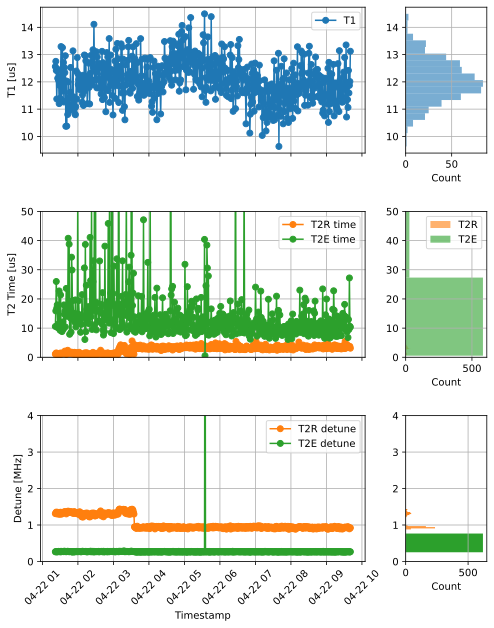

In [184]:
plot_t1_t2_timeseries_with_hist()

T1 Correlation Matrix (Pearson r):
          q4_T1     q5_T1     q6_T1
q4_T1  1.000000  0.162032 -0.179356
q5_T1  0.162032  1.000000  0.111150
q6_T1 -0.179356  0.111150  1.000000
T1 R² Matrix:
          q4_T1     q5_T1     q6_T1
q4_T1  1.000000  0.026254  0.032169
q5_T1  0.026254  1.000000  0.012354
q6_T1  0.032169  0.012354  1.000000


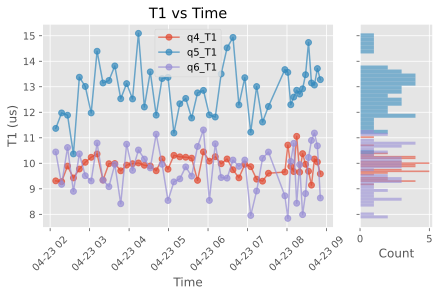

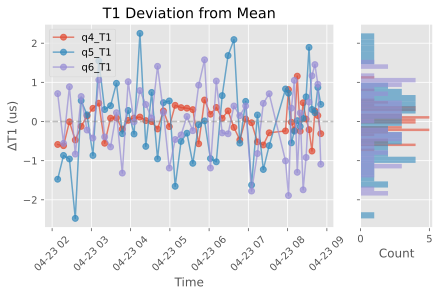

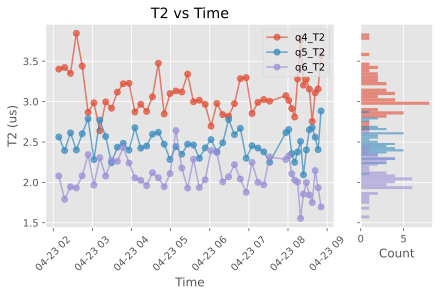

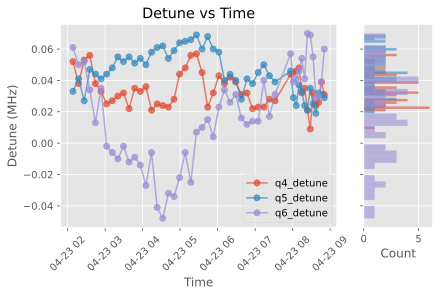

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
# 讀取 CSV
df = pd.read_csv("data_fitting/csv/q456_monitor_log.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.style.use("ggplot")  

def plot_with_hist(x, ys, ylabel, title, ylim:False):
    fig = plt.figure(figsize=(6, 4), constrained_layout=True)
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05, figure=fig)

    # 主圖 (time vs value)
    ax0 = plt.subplot(gs[0])
    for label, y in ys.items():
        ax0.plot(x, y, label=label, marker='o', alpha=0.7)
    ax0.set_title(title)
    ax0.set_xlabel("Time")
    ax0.set_ylabel(ylabel)
    ax0.legend()
    ax0.tick_params(axis='x', rotation=45)

    # 垂直直方圖
    ax1 = plt.subplot(gs[1], sharey=ax0)
    for label, y in ys.items():
        ax1.hist(y, bins=30, orientation='horizontal', alpha=0.6, label=label)
    ax1.set_xlabel("Count")
    ax1.tick_params(labelleft=False)
    if ylim:
        ax0.set_ylim(-0.5, 0.5)

def plot_with_hist_delta(x, ys, ylabel, title):
    fig = plt.figure(figsize=(6, 4), constrained_layout=True)
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05, figure=fig)

    # 主圖 (Time vs Δvalue)
    ax0 = plt.subplot(gs[0])
    for label, y in ys.items():
        delta_y = y - y.mean()
        ax0.plot(x, delta_y, label=label, marker='o', alpha=0.7)
    ax0.set_title(title)
    ax0.set_xlabel("Time")
    ax0.set_ylabel(f"Δ{ylabel}")
    ax0.axhline(0, linestyle='--', color='gray', alpha=0.5)
    ax0.legend()
    ax0.tick_params(axis='x', rotation=45)

    # Histogram (of Δvalue)
    ax1 = plt.subplot(gs[1], sharey=ax0)
    for label, y in ys.items():
        delta_y = y - y.mean()
        ax1.hist(delta_y, bins=30, orientation='horizontal', alpha=0.6, label=label)
    ax1.set_xlabel("Count")
    ax1.tick_params(labelleft=False)

# 1. T1 vs Time
plot_with_hist(
    df['timestamp'],
    {'q4_T1': df['q4_T1'], 'q5_T1': df['q5_T1'], 'q6_T1': df['q6_T1']},
    ylabel="T1 (us)",
    title="T1 vs Time",
    ylim=False
)
plot_with_hist_delta(
    df['timestamp'],
    {'q4_T1': df['q4_T1'], 'q5_T1': df['q5_T1'], 'q6_T1': df['q6_T1']},
    ylabel="T1 (us)",
    title="T1 Deviation from Mean"
)

# 2. T2 vs Time
plot_with_hist(
    df['timestamp'],
    {'q4_T2': df['q4_T2'], 'q5_T2': df['q5_T2'], 'q6_T2': df['q6_T2']},
    ylabel="T2 (us)",
    title="T2 vs Time",
    ylim=False
)

# 3. Detune vs Time
plot_with_hist(
    df['timestamp'],
    {'q4_detune': df['q4_detune'], 'q5_detune': df['q5_detune'], 'q6_detune': df['q6_detune']},
    ylabel="Detune (MHz)",
    title="Detune vs Time",
    ylim=False
)

t1_df = df[["q4_T1", "q5_T1", "q6_T1"]]

corr_matrix = t1_df.corr(method='pearson')

print("T1 Correlation Matrix (Pearson r):")
print(corr_matrix)
r_squared_matrix = corr_matrix**2
print("T1 R² Matrix:")
print(r_squared_matrix)

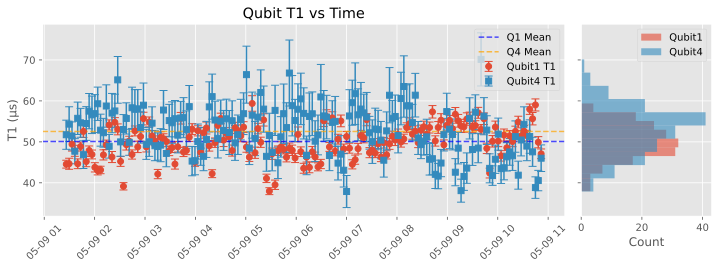

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 讀取 CSV
csv_filename = "Q14_T1_T2_results_2.csv"
df = pd.read_csv(csv_filename)
df.columns = df.columns.str.strip()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 分出 Qubit1 和 Qubit4
q1 = df[df["Qubit"] == "Qubit1"]
q4 = df[df["Qubit"] == "Qubit4"]

# 建立單一大圖與排版
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 1], hspace=0.3, wspace=0.05)

# --- T1 vs Time ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(q1["Timestamp"], q1["T1 (us)"]*2, yerr=q1["T1 sigma"], fmt='o', label="Qubit1 T1", capsize=4)
ax1.errorbar(q4["Timestamp"], q4["T1 (us)"], yerr=q4["T1 sigma"], fmt='s', label="Qubit4 T1", capsize=4)

# 平均線
ax1.axhline(q1["T1 (us)"].mean()*2, color='blue', linestyle='--', alpha=0.7, label="Q1 Mean")
ax1.axhline(q4["T1 (us)"].mean(), color='orange', linestyle='--', alpha=0.7, label="Q4 Mean")

ax1.set_ylabel("T1 (μs)")
ax1.set_title("Qubit T1 vs Time")
ax1.grid(True)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- T1 Histogram ---
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.hist(q1["T1 (us)"]*2, bins=10, orientation='horizontal', alpha=0.6, label="Qubit1")
ax2.hist(q4["T1 (us)"], bins=10, orientation='horizontal', alpha=0.6, label="Qubit4")
ax2.set_xlabel("Count")
ax2.tick_params(labelleft=False)
ax2.legend()

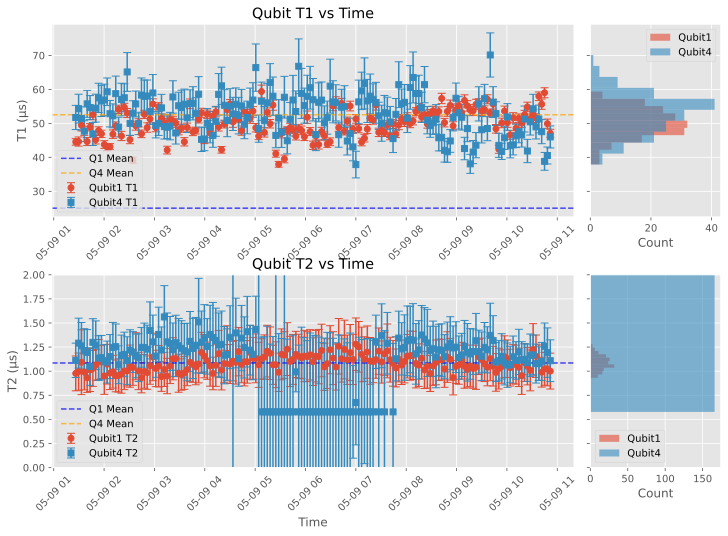

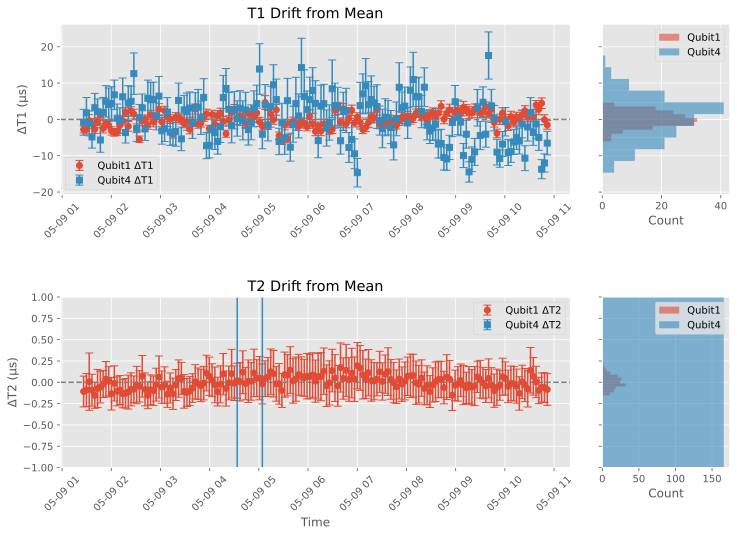

T1 correlation Q1 vs Q4: r = -0.147, R² = 0.022
T2 correlation Q1 vs Q4: r = 0.038, R² = 0.001


In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 讀取 CSV
csv_filename = "Q14_T1_T2_results_2.csv"
df = pd.read_csv(csv_filename)
df.columns = df.columns.str.strip()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 分出 Qubit1 和 Qubit4
q1 = df[df["Qubit"] == "Qubit1"]
q4 = df[df["Qubit"] == "Qubit4"]

# 建立單一大圖與排版
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 1], hspace=0.3, wspace=0.05)

# --- T1 vs Time ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(q1["Timestamp"], q1["T1 (us)"]*2, yerr=q1["T1 sigma"], fmt='o', label="Qubit1 T1", capsize=4)
ax1.errorbar(q4["Timestamp"], q4["T1 (us)"], yerr=q4["T1 sigma"], fmt='s', label="Qubit4 T1", capsize=4)

# 平均線
ax1.axhline(q1["T1 (us)"].mean()*2, color='blue', linestyle='--', alpha=0.7, label="Q1 Mean")
ax1.axhline(q4["T1 (us)"].mean(), color='orange', linestyle='--', alpha=0.7, label="Q4 Mean")

ax1.set_ylabel("T1 (μs)")
ax1.set_title("Qubit T1 vs Time")
ax1.grid(True)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- T1 Histogram ---
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.hist(q1["T1 (us)"]*2, bins=10, orientation='horizontal', alpha=0.6, label="Qubit1")
ax2.hist(q4["T1 (us)"], bins=10, orientation='horizontal', alpha=0.6, label="Qubit4")
ax2.set_xlabel("Count")
ax2.tick_params(labelleft=False)
ax2.legend()

# --- T2 vs Time ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.errorbar(q1["Timestamp"], q1["T2 (us)"], yerr=q1["T2 sigma"], fmt='o', label="Qubit1 T2", capsize=4)
ax3.errorbar(q4["Timestamp"], q4["T2 (us)"], yerr=q4["T2 sigma"], fmt='s', label="Qubit4 T2", capsize=4)

# 平均線
ax3.axhline(q1["T2 (us)"].mean(), color='blue', linestyle='--', alpha=0.7, label="Q1 Mean")
ax3.axhline(q4["T2 (us)"].mean(), color='orange', linestyle='--', alpha=0.7, label="Q4 Mean")

ax3.set_xlabel("Time")
ax3.set_ylabel("T2 (μs)")
ax3.set_title("Qubit T2 vs Time")
ax3.grid(True)
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# --- T2 Histogram ---
ax4 = fig.add_subplot(gs[1, 1], sharey=ax3)
ax4.hist(q1["T2 (us)"], bins=10, orientation='horizontal', alpha=0.6, label="Qubit1")
ax4.hist(q4["T2 (us)"], bins=10, orientation='horizontal', alpha=0.6, label="Qubit4")
ax4.set_xlabel("Count")
ax4.tick_params(labelleft=False)
ax4.legend()
ax4.set_ylim(0, 2)
plt.subplots_adjust(hspace=0.6, wspace=0.15)
plt.savefig("Qubit_T1_T2_Analysis.jpg")

df["Delta_T1"] = None
df["Delta_T2"] = None


for q in ["Qubit1", "Qubit4"]:
    m = df["Qubit"] == q
    df.loc[m, "Delta_T1"] = df.loc[m, "T1 (us)"] - df.loc[m, "T1 (us)"].mean()
    df.loc[m, "Delta_T2"] = df.loc[m, "T2 (us)"] - df.loc[m, "T2 (us)"].mean()


q1 = df[df["Qubit"] == "Qubit1"]
q4 = df[df["Qubit"] == "Qubit4"]


fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 1], hspace=0.6, wspace=0.1)

# --- ΔT1 vs Time ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(q1["Timestamp"], q1["Delta_T1"], yerr=q1["T1 sigma"], fmt='o', label="Qubit1 ΔT1", capsize=4)
ax1.errorbar(q4["Timestamp"], q4["Delta_T1"], yerr=q4["T1 sigma"], fmt='s', label="Qubit4 ΔT1", capsize=4)
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("ΔT1 (μs)")
ax1.set_title("T1 Drift from Mean")
ax1.grid(True)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- ΔT1 Histogram ---
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.hist(q1["Delta_T1"].dropna(), bins=10, orientation='horizontal', alpha=0.6, label="Qubit1")
ax2.hist(q4["Delta_T1"].dropna(), bins=10, orientation='horizontal', alpha=0.6, label="Qubit4")
ax2.set_xlabel("Count")
ax2.tick_params(labelleft=False)
ax2.legend()

# --- ΔT2 vs Time ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.errorbar(q1["Timestamp"], q1["Delta_T2"], yerr=q1["T2 sigma"], fmt='o', label="Qubit1 ΔT2", capsize=4)
ax3.errorbar(q4["Timestamp"], q4["Delta_T2"], yerr=q4["T2 sigma"], fmt='s', label="Qubit4 ΔT2", capsize=4)
ax3.axhline(0, color='gray', linestyle='--')
ax3.set_xlabel("Time")
ax3.set_ylabel("ΔT2 (μs)")
ax3.set_title("T2 Drift from Mean")
ax3.grid(True)
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# --- ΔT2 Histogram ---
ax4 = fig.add_subplot(gs[1, 1], sharey=ax3)
ax4.hist(q1["Delta_T2"].dropna(), bins=10, orientation='horizontal', alpha=0.6, label="Qubit1")
ax4.hist(q4["Delta_T2"].dropna(), bins=10, orientation='horizontal', alpha=0.6, label="Qubit4")
ax4.set_xlabel("Count")
ax4.tick_params(labelleft=False)
ax4.set_ylim(-1,1)
ax4.legend()

plt.subplots_adjust(hspace=0.6, wspace=0.1)
plt.savefig("Qubit_T1_T2_Delta_Hist.jpg")
plt.show()

## correaction ##
merged_t1 = pd.merge(
    q1[["Timestamp", "T1 (us)"]],
    q4[["Timestamp", "T1 (us)"]],
    on="Timestamp",
    suffixes=("_q1", "_q4")
)

merged_t2 = pd.merge(
    q1[["Timestamp", "T2 (us)"]],
    q4[["Timestamp", "T2 (us)"]],
    on="Timestamp",
    suffixes=("_q1", "_q4")
)

r_t1 = np.corrcoef(merged_t1["T1 (us)_q1"], merged_t1["T1 (us)_q4"])[0, 1]
r_t2 = np.corrcoef(merged_t2["T2 (us)_q1"], merged_t2["T2 (us)_q4"])[0, 1]

print(f"T1 correlation Q1 vs Q4: r = {r_t1:.3f}, R² = {r_t1**2:.3f}")
print(f"T2 correlation Q1 vs Q4: r = {r_t2:.3f}, R² = {r_t2**2:.3f}")

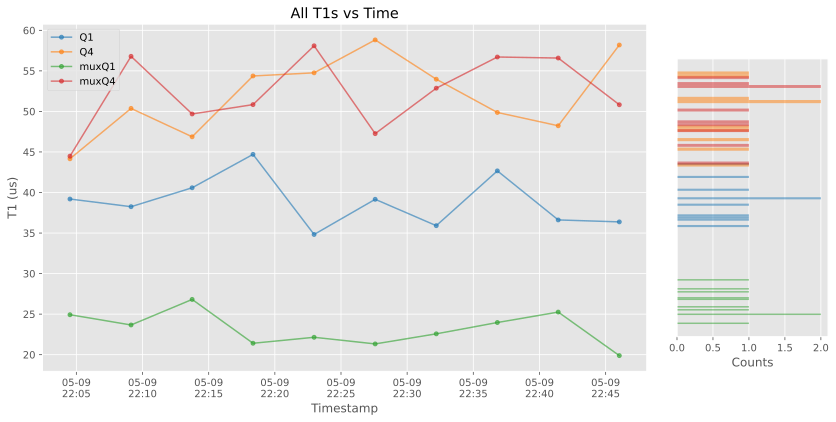

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 讀取資料
csv_filename = "interleve.csv"
df = pd.read_csv(csv_filename)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 欲畫的 T1 欄位和標籤
t1_columns = {
    "Q1 T1 (us)": "Q1",
    "Q1 T4 (us)": "Q4",
    "mux Q1 T1 (us)": "muxQ1",
    "mux Q4 T1 (us)": "muxQ4",
}

colors = {
    "Q1": "tab:blue",
    "Q4": "tab:orange",
    "muxQ1": "tab:green",
    "muxQ4": "tab:red"
}

# 主圖：時間 vs T1（所有類型）
fig, ax_scatter = plt.subplots(figsize=(12, 6))
ax_hist = ax_scatter.inset_axes([1.05, 0.1, 0.25, 0.8])

for col, label in t1_columns.items():
    ax_scatter.plot(df["Timestamp"], df[col], 'o-', label=label, alpha=0.6, markersize=4, color=colors[label])
    ax_hist.hist(df[col], bins=30, orientation='horizontal', alpha=0.5, label=label, color=colors[label])

# 美化
ax_scatter.set_title("All T1s vs Time")
ax_scatter.set_xlabel("Timestamp")
ax_scatter.set_ylabel("T1 (us)")
ax_scatter.legend()
ax_scatter.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))

ax_hist.set_yticks([])
ax_hist.set_xlabel("Counts")

plt.tight_layout()
# os.makedirs("t1_images/plot_summary", exist_ok=True)
# plt.savefig("t1_images/plot_summary/all_T1_vs_time.png", dpi=300)
# plt.show()


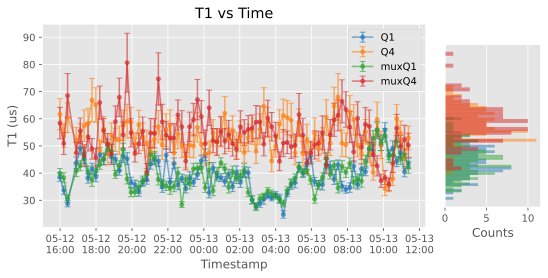

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 讀取資料
csv_filename = "interleve_5.csv"
df = pd.read_csv(csv_filename)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 欲畫的 T1 欄位和標籤
t1_columns = {
    "Q1 T1 (us)": "Q1",
    "Q1 T4 (us)": "Q4",
    "mux Q1 T1 (us)": "muxQ1",
    "mux Q4 T1 (us)": "muxQ4",
}

# 對應的 sigma 欄位
sigma_columns = {
    "Q1 T1 (us)": "Q1 T1 sigma",
    "Q1 T4 (us)": "Q4 T1 sigma",
    "mux Q1 T1 (us)": "muxQ1 T1 sigma",
    "mux Q4 T1 (us)": "muxQ4 T1 sigma",
}

colors = {
    "Q1": "tab:blue",
    "Q4": "tab:orange",
    "muxQ1": "tab:green",
    "muxQ4": "tab:red"
}

# 主圖：時間 vs T1（所有類型）
fig, ax_scatter = plt.subplots(figsize=(8, 4))
ax_hist = ax_scatter.inset_axes([1.05, 0.1, 0.25, 0.8])

for col, label in t1_columns.items():
    y = df[col]
    yerr = df[sigma_columns[col]]
    x = df["Timestamp"]
    
    # 有誤差條的折線圖
    ax_scatter.errorbar(x, y, yerr=yerr, fmt='o-', label=label, alpha=0.6,
                        markersize=4, color=colors[label], capsize=3)
    
    # Histogram
    ax_hist.hist(y, bins=30, orientation='horizontal', alpha=0.5, label=label, color=colors[label])

# 美化
ax_scatter.set_title("T1 vs Time")
ax_scatter.set_xlabel("Timestamp")
ax_scatter.set_ylabel("T1 (us)")
ax_scatter.legend()
ax_scatter.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))

ax_hist.set_yticks([])
ax_hist.set_xlabel("Counts")

plt.tight_layout()

os.makedirs("t1_images_5/plot_summary", exist_ok=True)
plt.savefig("t1_images_5/plot_summary/all_T1_vs_time.png", dpi=300)
plt.show()


 C:\Users\QEL\AppData\Local\Temp\ipykernel_43436\842456924.py: 64

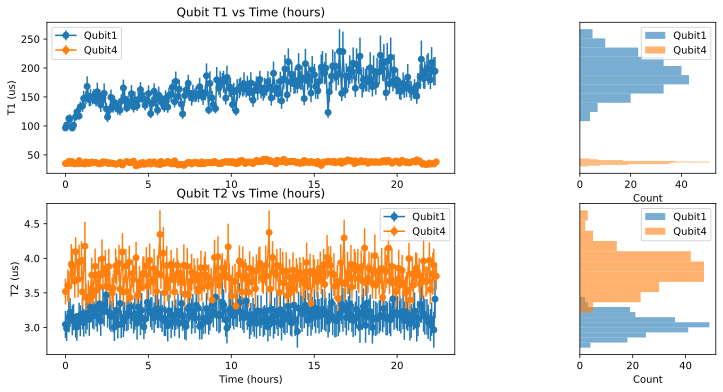

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 讀入資料
df = pd.read_csv(r"C:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\csutscrip\Q14_T1_T2_results_interleve.csv")

# 時間轉換
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hours'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds() / 3600

# 設定顏色
color_map = {
    'Q1': 'tab:blue',
    'Q4': 'tab:orange',
    # 若有更多 qubit，可以加在這
}

# 建立 gridspec
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[3, 0.1, 1], height_ratios=[1, 1], wspace=0.3)

# T1 plot
ax_t1 = fig.add_subplot(gs[0, 0])
for q in df['Qubit'].unique():
    df_q = df[df['Qubit'] == q]
    ax_t1.errorbar(df_q['Hours'], df_q['T1 (us)'], yerr=df_q['T1 sigma'],
                   label=q, marker='o', linestyle='-', color=color_map.get(q, None))
ax_t1.set_ylabel("T1 (us)")
ax_t1.set_title("Qubit T1 vs Time (hours)")
ax_t1.legend()

# T1 histogram by Qubit
ax_t1_hist = fig.add_subplot(gs[0, 2])
for q in df['Qubit'].unique():
    df_q = df[df['Qubit'] == q]
    ax_t1_hist.hist(df_q['T1 (us)'], bins=10, orientation='horizontal',
                    alpha=0.6, label=q, color=color_map.get(q, None))
ax_t1_hist.set_xlabel("Count")
ax_t1_hist.set_yticks([])
ax_t1_hist.legend()

# T2 plot
ax_t2 = fig.add_subplot(gs[1, 0])
for q in df['Qubit'].unique():
    df_q = df[df['Qubit'] == q]
    ax_t2.errorbar(df_q['Hours'], df_q['T2 (us)'], yerr=df_q['T2 sigma'],
                   label=q, marker='o', linestyle='-', color=color_map.get(q, None))
ax_t2.set_ylabel("T2 (us)")
ax_t2.set_xlabel("Time (hours)")
ax_t2.set_title("Qubit T2 vs Time (hours)")
ax_t2.legend()

# T2 histogram by Qubit
ax_t2_hist = fig.add_subplot(gs[1, 2])
for q in df['Qubit'].unique():
    df_q = df[df['Qubit'] == q]
    ax_t2_hist.hist(df_q['T2 (us)'], bins=10, orientation='horizontal',
                    alpha=0.6, label=q, color=color_map.get(q, None))
ax_t2_hist.set_xlabel("Count")
ax_t2_hist.set_yticks([])
ax_t2_hist.legend()

plt.tight_layout()
plt.show()
